# Lab - YOLOv4-Tiny Part 6 - Pretrained YOLOv4-Tiny Webcam Inference
## E6792 Spring 2026

In this part we do inference with YOLOv4-Tiny through the webcam. You will load the pretrained YOLOv4-Tiny [Darknet](https://pjreddie.com/darknet/) weights into a PyTorch implementation of the model. The weights we are using were trained on the **COCO (Common Objects in COntext)** computer vision dataset comprised of 80 classes of common objects. Read more about the dataset [here](https://cocodataset.org/#home). 

**Complete this notebook on the Jetson Nano.**

In [1]:
# import standard libraries
import torch
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# import custom libraries
from darknet_utils.darknet_to_pytorch import load_darknet_as_pytorch
from darknet_utils.utils import plot_boxes_cv2, post_processing, nms_cpu
from darknet_utils.torch_utils import detect
from darknet_utils.inference import image_inference, webcam_inference, get_class_names
from darknet_utils.download_images import download_images

# define weights and configuration file paths
cfg_path = './cfg/yolov4-COCO-pretrained.cfg'
weights_path = './weights/yolov4-tiny.weights'

device = 'cuda'

%load_ext autoreload
%autoreload 2

%matplotlib inline

The PyTorch YOLOv4-Tiny model is defined in **darknet_utils/darknet_model.py**. Note that the model contains a "load_weights" function. The model is also defined by parsing the configuration file. This allows for easy reconfiguration and versioning of the model. 

<font color="red"><strong>TODO:</strong></font>  Load the pretrained YOLOv4-Tiny weights into the PyTorch implementation with the function **load_darknet_as_pytorch()**.

In [2]:
###################################################
# TODO: Use load_darknet_as_pytorch() to load the #
#       pretrained YOLOv4-Tiny PyTorch model      #
###################################################

pretrained_yolo_tiny = load_darknet_as_pytorch(cfg_path, weights_path)
pretrained_yolo_tiny = pretrained_yolo_tiny.to(device)
pretrained_yolo_tiny.eval()

###################################################
# END TODO                                        #
###################################################

Darknet(
  (models): ModuleList(
    (0): Sequential(
      (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (leaky1): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (1): Sequential(
      (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (leaky2): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (2): Sequential(
      (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (leaky3): LeakyReLU(negative_slope=0.1, inplace=True)
    )
    (3): EmptyModule()
    (4): Sequential(
      (conv4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn4):


<font color="red"><strong>TODO:</strong></font>  Next you will download images for sample inference. We will use **download_images()** as we did in previous labs. Note that the model was trained on 80 classes of objects. You may want to adjust your query to reflect these classes. See **ms_coco_classnames.txt** for the full list of classes. 

In [ ]:
###################################################
# TODO: Download at least 3 images with           #
#       download_n_images() to use for inference. #
###################################################

query = 'sports'
n = 3

download_images(query, n)

###################################################
# END TODO                                        #
###################################################

<font color="red"><strong>TODO:</strong></font>  In **darknet_utils.inference**, implement the function **get_class_names()**. 

In [6]:
###################################################
# TODO: Use get_class_names() to load the COCO    #
#       classes as a dictionary of class indices  #
#       and class names.                          #
###################################################

class_names = {}
classes_path = 'ms_coco_classnames.txt'
class_names = get_class_names(classes_path)
print(class_names)

###################################################
# END TODO                                        #
###################################################

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

<font color="red"><strong>TODO:</strong></font>  In **darknet_utils.inference** complete the function **image_inference()**. Then use it to perform inference with the pretrained YOLOv4-Tiny on at least 3 of the images you downloaded. You will need to define a confidence threshold and an [NMS threshold](https://learnopencv.com/non-maximum-suppression-theory-and-implementation-in-pytorch/#:~:text=Deep%20Learning%20Face%20Detection%20Object,out%20of%20many%20overlapping%20entities.) for the model.

In [ ]:
###################################################
# TODO: Complete image_inference() and use it to  #
#       perform inference on the images you       #
#       downloaded.                               #
###################################################
CONF_THRESH = 0.4
NMS_THRESH = 0.4

for img in image_files[:3]:
    image_inference(
        img,
        pretrained_yolo_tiny,
        CONF_THRESH,
        NMS_THRESH,
        class_names
    )


###################################################
# END TODO                                        #
###################################################

How do the detections change as you adjust the confidence and NMS thresholds?

<font color="red"><strong>TODO:</strong></font>  Your answer here.

<font color="red"><strong>TODO:</strong></font> Use the function **webcam_inference()** to do pretrained inference through the webcam of the Jetson Nano.

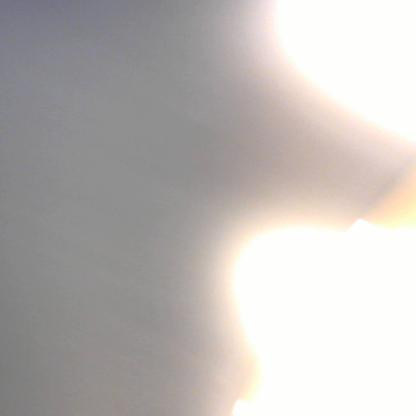

In [ ]:
###################################################
# TODO: Use the function webcam_inference() by    #
#       running this cell.                        #
###################################################

webcam_inference(pretrained_yolo_tiny, class_names=class_names)

###################################################
# END TODO                                        #
###################################################


#### Questions:
* How does the YOLOv4-Tiny inference compare to the live inferences you have performed in previous labs? 
* What happens if you increase the resolution of the live inference? 
* Experiment with detecting and describe edge cases where the detection accuracy is poor.

<font color="red"><strong>TODO:</strong></font> Your answer here.

<font color="red"><strong>TODO:</strong></font>  Insert a screenshot of your webcam pretrained inference with some good detections of COCO objects.

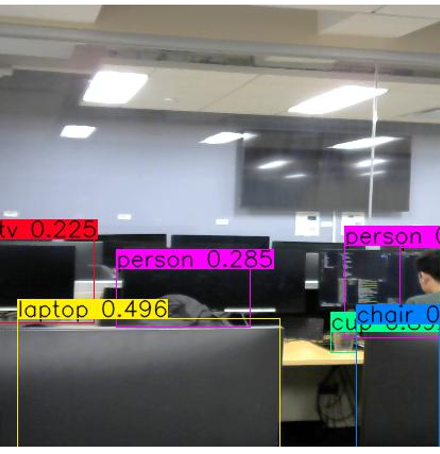 



I asked for permission!!